In [57]:
import pandas as pd
import re
import string
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

## 1. Carregar dados brutos

In [58]:
df = pd.read_excel('NPS-Comentarios-2024-Louveira_VilaAndrade.xlsx')
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

Shape: (1085, 8)


,Ano,Centro,Mes,Semana,Data Avaliação,Comentario,classificacao,NPS
0,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,"Maior variedade, não tinha tudo o que eu procurava , apesar de muitas opções.",promotor,1
1,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,-,promotor,1
2,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,-,detrator,-1
3,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-02,Nada a declarar,promotor,1
4,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-02,Tudo certinho por enquanto tah ótimo.,promotor,1


Ano                        int64
Centro                    object
Mes                       object
Semana                     int64
Data Avaliação    datetime64[ns]
Comentario                object
classificacao             object
NPS                        int64
dtype: object

## 2. Filtrar registros com comentários válidos

In [59]:
comentario_mask = df["Comentario"].notna() & df["Comentario"].astype(str).str.strip().ne("")
df_com_comentario = df[comentario_mask].copy()

print("Shape:", df_com_comentario.shape)
display(df_com_comentario.head())
display(df_com_comentario.dtypes)

Shape: (1085, 8)


,Ano,Centro,Mes,Semana,Data Avaliação,Comentario,classificacao,NPS
0,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,"Maior variedade, não tinha tudo o que eu procurava , apesar de muitas opções.",promotor,1
1,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,-,promotor,1
2,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-01,-,detrator,-1
3,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-02,Nada a declarar,promotor,1
4,2024,L5082-VILA ANDRADE (1346),jan,1,2024-01-02,Tudo certinho por enquanto tah ótimo.,promotor,1


Ano                        int64
Centro                    object
Mes                       object
Semana                     int64
Data Avaliação    datetime64[ns]
Comentario                object
classificacao             object
NPS                        int64
dtype: object

## 3. Garantir recursos do NLTK e carregar o modelo spaCy

In [60]:
resources = [
    ("punkt", "tokenizers/punkt"),
    ("punkt_tab", "tokenizers/punkt_tab"),
    ("stopwords", "corpora/stopwords"),
]

for resource, locator in resources:
    try:
        nltk.data.find(locator)
    except LookupError:
        nltk.download(resource, quiet=True)

nlp = spacy.load("pt_core_news_sm")
print("Recursos carregados e modelo spaCy pronto.")

Recursos carregados e modelo spaCy pronto.


## 4. Tokenizar comentários com NLTK

In [61]:
df_tokens = df_com_comentario.copy()
df_tokens["comentario_str"] = df_tokens["Comentario"].astype(str)
df_tokens["tokens_nltk"] = df_tokens["comentario_str"].apply(word_tokenize)

print("Pré-visualização da tokenização com NLTK:")
display(df_tokens[["Comentario", "tokens_nltk"]].head())

Pré-visualização da tokenização com NLTK:


,Comentario,tokens_nltk
0,"Maior variedade, não tinha tudo o que eu procurava , apesar de muitas opções.","[Maior, variedade, ,, não, tinha, tudo, o, que, eu, procurava, ,, apesar, de, muitas, opções, .]"
1,-,[-]
2,-,[-]
3,Nada a declarar,"[Nada, a, declarar]"
4,Tudo certinho por enquanto tah ótimo.,"[Tudo, certinho, por, enquanto, tah, ótimo, .]"


## 5. Limpar texto, remover stopwords/conjugações e lematizar com spaCy

In [62]:
EMOJI_PATTERN = re.compile(
    "["        "\U0001F1E0-\U0001F1FF"
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]",
    flags=re.UNICODE,
)
ALLOWED_PATTERN = re.compile(r"[^a-zà-ÿ0-9]", flags=re.IGNORECASE)
ONLY_PUNCTUATION = set(string.punctuation)

stopwords_pt = set(stopwords.words("portuguese"))
stopwords_pt.difference_update({"não", "ter"})

TER_CONJUGATIONS = {
    "ter", "tendo", "tido", "tida", "tidos", "tidas",
    "tenho", "tens", "tem", "temos", "tendes", "têm",
    "tenha", "tenhas", "tenhamos", "tenhais", "tenham",
    "tinha", "tinhas", "tínhamos", "tínheis", "tinham", "tinhamos",
    "tive", "tiveste", "teve", "tivemos", "tivestes", "tiveram",
    "tivera", "tiveras", "tivéramos", "tivéreis",
    "tiver", "tiveres", "tivermos", "tiverdes", "tiverem",
    "tivesse", "tivesses", "tivéssemos", "tivésseis", "tivessem",
    "terei", "terás", "terá", "teremos", "tereis", "terão", "terao",
    "teria", "terias", "teríamos", "teríeis", "teriam",
}


def limpar_token(token: str) -> str:
    sem_emoji = emoji.replace_emoji(token, replace="")
    sem_hashtag = sem_emoji.replace("#", "")
    sem_emoticon = EMOJI_PATTERN.sub("", sem_hashtag)
    normalizado = ALLOWED_PATTERN.sub("", sem_emoticon.lower())
    return normalizado


def limpar_tokens(tokens):
    limpos = []
    for token in tokens:
        if not token or all(char in ONLY_PUNCTUATION for char in token):
            continue
        token_norm = limpar_token(token)
        if len(token_norm) <= 1:
            continue
        if not token_norm.isalpha():
            continue
        if token_norm in stopwords_pt:
            continue
        if token_norm in TER_CONJUGATIONS:
            continue
        limpos.append(token_norm)
    return limpos


def lematizar_tokens(tokens):
    if not tokens:
        return []
    doc = nlp(" ".join(tokens))
    lemmas = []
    for token in doc:
        lemma = token.lemma_.lower()
        if lemma == "-pron-":
            lemma = token.text.lower()
        lemmas.append(ALLOWED_PATTERN.sub("", lemma))
    return [lemma for lemma in lemmas if lemma]


df_tokens["tokens_limpos"] = df_tokens["tokens_nltk"].apply(limpar_tokens)
df_tokens["tokens_lematizados"] = df_tokens["tokens_limpos"].apply(lematizar_tokens)

mask_multi_palavra = df_tokens["tokens_limpos"].apply(len) > 1
df_tratado = df_tokens[mask_multi_palavra].copy()
df_tratado["comentario_limpo"] = df_tratado["tokens_limpos"].apply(lambda toks: " ".join(toks))
df_tratado["comentario_lematizado"] = df_tratado["tokens_lematizados"].apply(lambda toks: " ".join(toks))
df_tratado = df_tratado.drop(columns=["comentario_str"])

print("Pré-visualização após limpeza e lematização:")
display(df_tratado[[
    "Comentario",
    "tokens_nltk",
    "tokens_limpos",
    "tokens_lematizados",
    "comentario_limpo",
    "comentario_lematizado",
]].head())
print(f"Total restante após limpeza: {len(df_tratado)}")

Pré-visualização após limpeza e lematização:


,Comentario,tokens_nltk,tokens_limpos,tokens_lematizados,comentario_limpo,comentario_lematizado
0,"Maior variedade, não tinha tudo o que eu procurava , apesar de muitas opções.","[Maior, variedade, ,, não, tinha, tudo, o, que, eu, procurava, ,, apesar, de, muitas, opções, .]","[maior, variedade, não, tudo, procurava, apesar, muitas, opções]","[grande, variedade, não, tudo, procurar, apesar, muito, opção]",maior variedade não tudo procurava apesar muitas opções,grande variedade não tudo procurar apesar muito opção
3,Nada a declarar,"[Nada, a, declarar]","[nada, declarar]","[nada, declarar]",nada declarar,nada declarar
4,Tudo certinho por enquanto tah ótimo.,"[Tudo, certinho, por, enquanto, tah, ótimo, .]","[tudo, certinho, enquanto, tah, ótimo]","[tudo, certinho, enquanto, tah, bom]",tudo certinho enquanto tah ótimo,tudo certinho enquanto tah bom
6,Eu procurei paleta de cabrito mss a Swift nao tem!,"[Eu, procurei, paleta, de, cabrito, mss, a, Swift, nao, tem, !]","[procurei, paleta, cabrito, mss, swift, nao]","[procurar, paleta, cabrito, mss, swift, nao]",procurei paleta cabrito mss swift nao,procurar paleta cabrito mss swift nao
8,Sempre sou muito bem atendida nesta loja.,"[Sempre, sou, muito, bem, atendida, nesta, loja, .]","[sempre, bem, atendida, nesta, loja]","[sempre, bem, atendido, emeste, loja]",sempre bem atendida nesta loja,sempre bem atendido emeste loja


Total restante após limpeza: 547


## 6. Preparar comentários por categoria NPS

In [63]:
categoria_map = {
    'promotor': 'promotor',
    'detrator': 'detrator',
    'neutro': 'neutro',
    'passivo': 'neutro',
}

df_tratado.loc[:, 'categoria_nps'] = (
    df_tratado['classificacao']
    .str.lower()
    .map(lambda x: categoria_map.get(x, x))
)

categorias_interesse = ['promotor', 'detrator', 'neutro']

contagem_por_categoria = (
    df_tratado['categoria_nps']
    .value_counts()
    .reindex(categorias_interesse, fill_value=0)
)
print('Distribuição de comentários tratados por categoria:')
print(contagem_por_categoria)


Distribuição de comentários tratados por categoria:
categoria_nps
promotor    404
detrator     74
neutro       69
Name: count, dtype: int64


## 7. Nuvem de palavras por categoria (contagem absoluta)

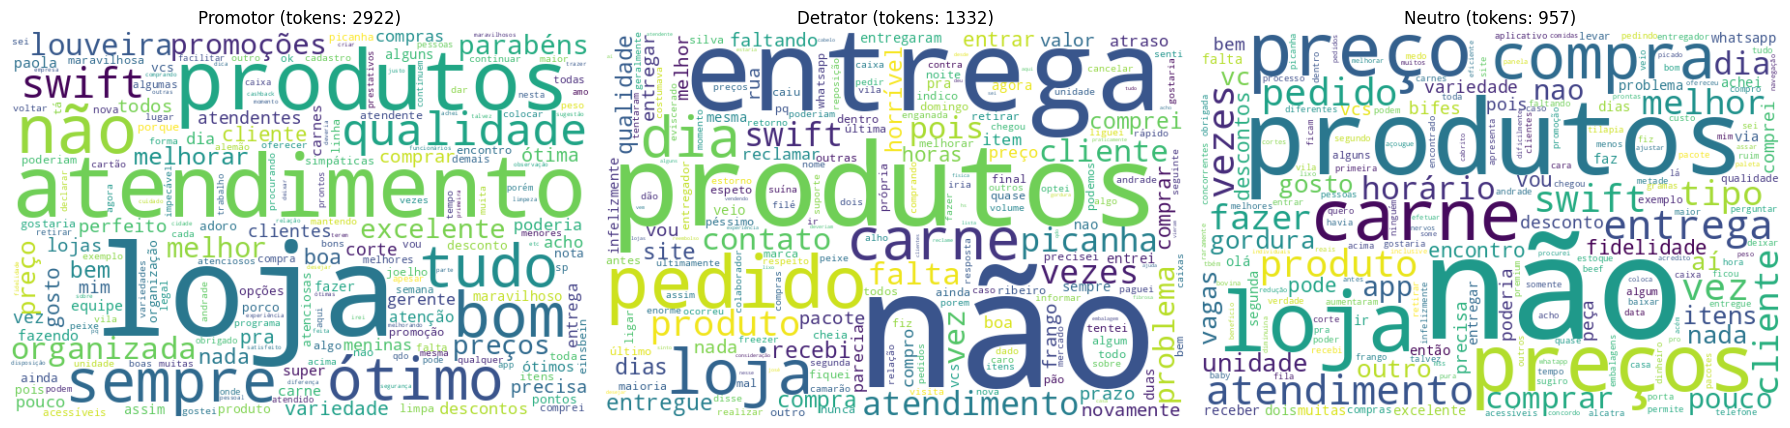

In [64]:
plt.figure(figsize=(18, 5))

for idx, categoria in enumerate(categorias_interesse, start=1):
    subset = df_tratado[df_tratado['categoria_nps'] == categoria]
    token_lists = subset['tokens_limpos']
    all_tokens = [tok for tokens in token_lists for tok in tokens]
    freq = Counter(all_tokens)

    plt.subplot(1, 3, idx)
    if freq:
        wc = WordCloud(width=600, height=400, background_color='white')
        wc.generate_from_frequencies(freq)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{categoria.title()} (tokens: {len(all_tokens)})')
    else:
        plt.text(0.5, 0.5, 'Sem dados', ha='center', va='center', fontsize=14)
        plt.axis('off')
        plt.title(f'{categoria.title()} (sem tokens)')

plt.tight_layout()
plt.show()


## 8. Termos mais relevantes por categoria com TF-IDF (unigramas)

In [65]:
def calcular_tfidf_por_categoria(df_categoria, max_features=40, top_n=15):
    if df_categoria.empty:
        return []
    vectorizer = TfidfVectorizer(
        tokenizer=lambda text: text.split(),
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 1),
        max_features=max_features,
    )
    matriz = vectorizer.fit_transform(df_categoria['comentario_lematizado'])
    media_scores = matriz.mean(axis=0).A1
    termos = vectorizer.get_feature_names_out()
    ranking = sorted(zip(termos, media_scores), key=lambda item: item[1], reverse=True)
    return ranking[:top_n]

resultados_tfidf = {}
for categoria in categorias_interesse:
    subset = df_tratado[df_tratado['categoria_nps'] == categoria]
    resultados_tfidf[categoria] = calcular_tfidf_por_categoria(subset)

linhas = []
for categoria, termos in resultados_tfidf.items():
    for termo, score in termos:
        linhas.append({'categoria': categoria, 'termo': termo, 'score_tfidf': score})

df_tfidf = pd.DataFrame(linhas)
if not df_tfidf.empty:
    display(df_tfidf)
else:
    print('Sem dados suficientes para calcular TF-IDF nas categorias solicitadas.')


,categoria,termo,score_tfidf
0,promotor,bom,0.124685
1,promotor,atendimento,0.107534
2,promotor,loja,0.099089
3,promotor,produto,0.098573
4,promotor,preço,0.069817
5,promotor,tudo,0.056771
6,promotor,promoção,0.054017
7,promotor,não,0.052752
8,promotor,sempre,0.051124
9,promotor,organizar,0.048568


## 9. Ranking TF-IDF (unigramas) — gráfico de barras

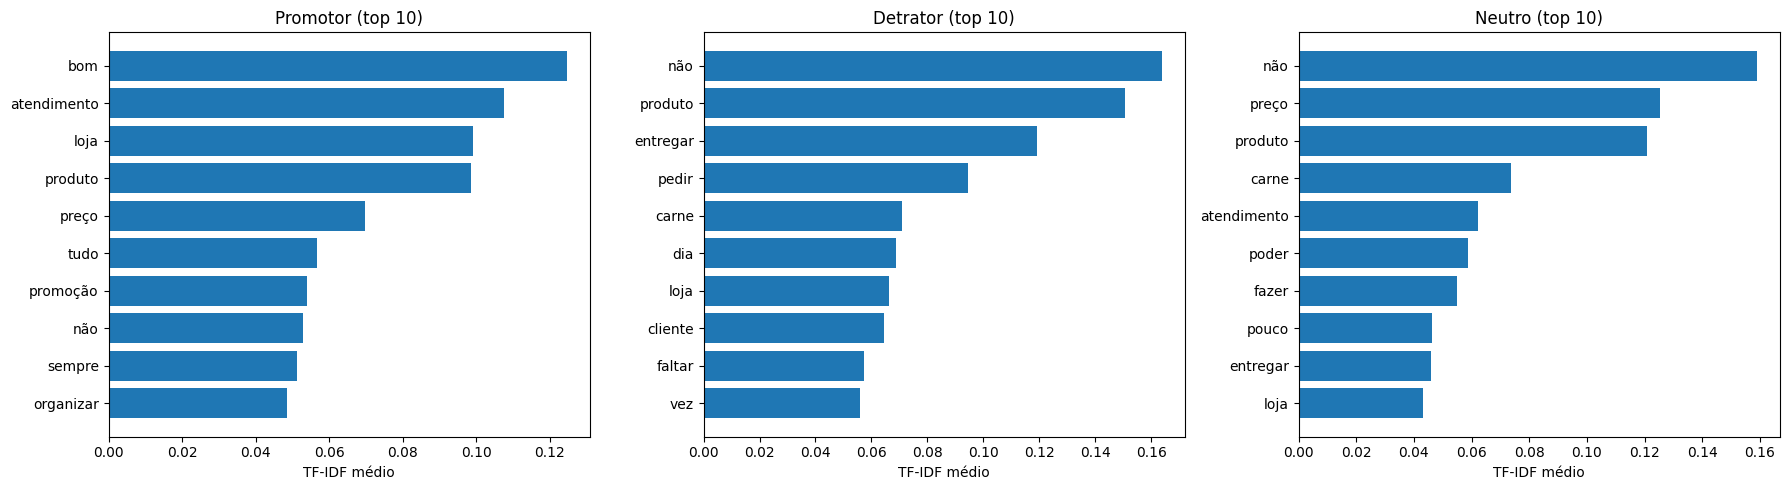

In [66]:
TOP_N_PLOT = 10
plt.figure(figsize=(18, 5))

for idx, categoria in enumerate(categorias_interesse, start=1):
    subset = df_tfidf[df_tfidf['categoria'] == categoria].nlargest(TOP_N_PLOT, 'score_tfidf')
    plt.subplot(1, 3, idx)
    if not subset.empty:
        plt.barh(subset['termo'][::-1], subset['score_tfidf'][::-1], color='#1f77b4')
        plt.title(f'{categoria.title()} (top {len(subset)})')
        plt.xlabel('TF-IDF médio')
    else:
        plt.text(0.5, 0.5, 'Sem dados', ha='center', va='center', fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()


## 9. Termos mais relevantes por categoria com TF-IDF (bi-gramas)

In [67]:
def calcular_tfidf_bigrama(df_categoria, max_features=40, top_n=15):
    if df_categoria.empty:
        return []
    vectorizer = TfidfVectorizer(
        tokenizer=lambda text: text.split(),
        token_pattern=None,
        lowercase=False,
        ngram_range=(2, 2),
        max_features=max_features,
    )
    matriz = vectorizer.fit_transform(df_categoria['comentario_lematizado'])
    media_scores = matriz.mean(axis=0).A1
    termos = vectorizer.get_feature_names_out()
    ranking = sorted(zip(termos, media_scores), key=lambda item: item[1], reverse=True)
    return ranking[:top_n]

resultados_tfidf_bi = {}
for categoria in categorias_interesse:
    subset = df_tratado[df_tratado['categoria_nps'] == categoria]
    resultados_tfidf_bi[categoria] = calcular_tfidf_bigrama(subset)

linhas_bi = []
for categoria, termos in resultados_tfidf_bi.items():
    for termo, score in termos:
        linhas_bi.append({'categoria': categoria, 'bi_grama': termo, 'score_tfidf': score})

df_tfidf_bi = pd.DataFrame(linhas_bi)
if not df_tfidf_bi.empty:
    display(df_tfidf_bi)
else:
    print('Sem dados suficientes para calcular TF-IDF de bi-gramas nas categorias solicitadas.')


,categoria,bi_grama,score_tfidf
0,promotor,bom atendimento,0.036813
1,promotor,tudo bom,0.029253
2,promotor,loja organizar,0.028693
3,promotor,atendimento bom,0.026994
4,promotor,loja louveira,0.024775
5,promotor,produto qualidade,0.019229
6,promotor,atendimento excelente,0.016179
7,promotor,organizar atendimento,0.016144
8,promotor,poder melhorar,0.015745
9,promotor,sempre bom,0.015477


## 10. Ranking TF-IDF (bi-gramas) — gráfico de barras

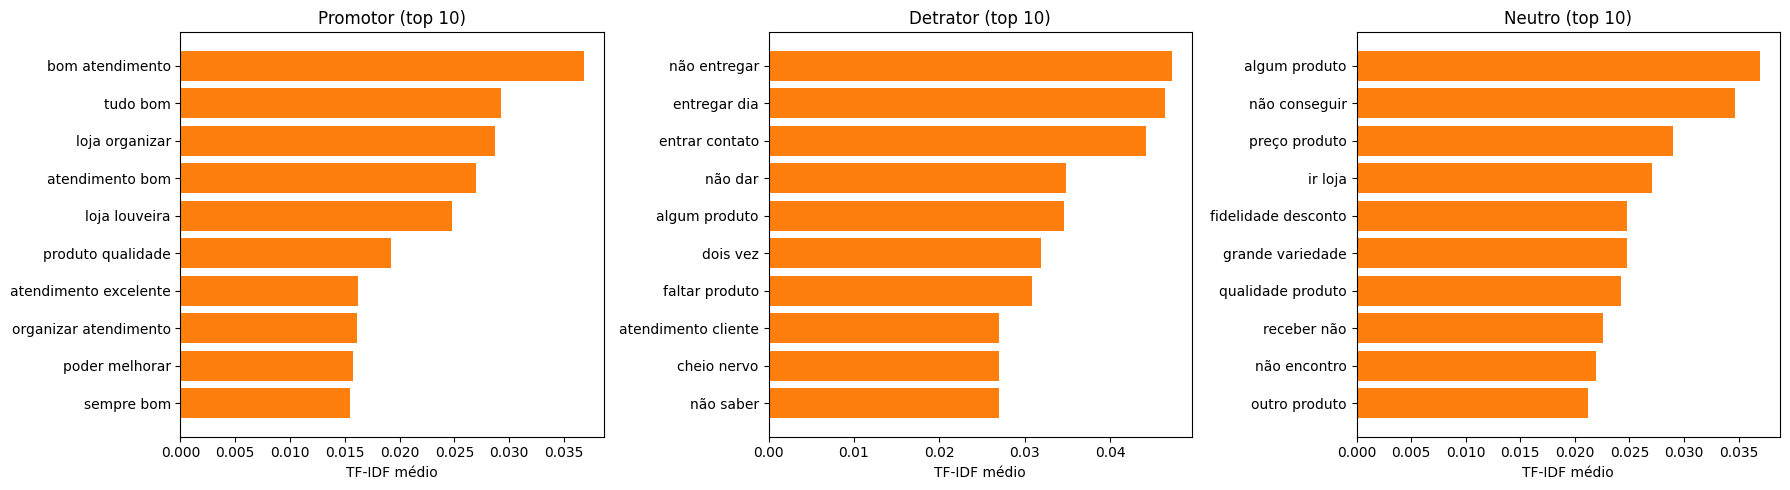

In [68]:
plt.figure(figsize=(18, 5))

for idx, categoria in enumerate(categorias_interesse, start=1):
    subset = df_tfidf_bi[df_tfidf_bi['categoria'] == categoria].nlargest(TOP_N_PLOT, 'score_tfidf')
    plt.subplot(1, 3, idx)
    if not subset.empty:
        plt.barh(subset['bi_grama'][::-1], subset['score_tfidf'][::-1], color='#ff7f0e')
        plt.title(f'{categoria.title()} (top {len(subset)})')
        plt.xlabel('TF-IDF médio')
    else:
        plt.text(0.5, 0.5, 'Sem dados', ha='center', va='center', fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()


## 10. Visualizar comentários tratados

In [69]:
pd.set_option('display.max_colwidth', None)
display(df_tratado[["comentario_limpo", "comentario_lematizado"]].head())

,comentario_limpo,comentario_lematizado
0,maior variedade não tudo procurava apesar muitas opções,grande variedade não tudo procurar apesar muito opção
3,nada declarar,nada declarar
4,tudo certinho enquanto tah ótimo,tudo certinho enquanto tah bom
6,procurei paleta cabrito mss swift nao,procurar paleta cabrito mss swift nao
8,sempre bem atendida nesta loja,sempre bem atendido emeste loja


## 11. Exportar resultado final

In [70]:
output_csv = "NPS-Comentarios-2024-Louveira_VilaAndrade_tokenizado.csv"
df_tratado.to_csv(output_csv, index=False)
print(f"Dados tratados salvos em {output_csv}")

Dados tratados salvos em NPS-Comentarios-2024-Louveira_VilaAndrade_tokenizado.csv
